In [ ]:
import MDAnalysis as mda
#import prolif as plf
import numpy as np
import pandas as ps
import matplotlib.pyplot as plt
import MDAnalysis.analysis.rms
#from MDAnalysis.lib import distances
from MDAnalysis.analysis import align
from MDAnalysis.analysis.rms import rmsd

In [3]:
#concatinate trajectories
!printf "0\nc\nc\nc\n" | gmx trjcat -f rep1.wrapF.xtc rep2.wrapF.xtc rep3.wrapF.xtc rep4.wrapF.xtc -o rep1234.wrapF.xtc -settime

                 :-) GROMACS - gmx trjcat, 2025.1-Homebrew (-:

Executable:   /opt/homebrew/bin/../Cellar/gromacs/2025.1/bin/gmx
Data prefix:  /opt/homebrew/bin/../Cellar/gromacs/2025.1
Working dir:  /Users/farjal/Library/CloudStorage/OneDrive-Chalmers/Documents/Generator/Moltiverse_analysis/3.Simulation_and_analysis/new_Set/2.Simulation_dardel_finalset/3895_simulation_p
Command line:
  gmx trjcat -f rep1.wrapF.xtc rep2.wrapF.xtc rep3.wrapF.xtc rep4.wrapF.xtc -o rep1234.wrapF.xtc -settime

Reading frame       1 time   20.000   


Enter the new start time (ps) for each file.
There are two special options, both disable sorting:

c (continue) - The start time is taken from the end
of the previous file. Use it when your continuation run
restarts with t=0.

l (last) - The time in this file will be changed the
same amount as in the previous. Use it when the time in the
new run continues from the end of the previous one,
since this takes possible overlap into account.

          File         

In [ ]:
trjname='PROTAC-1 in Chloroform'   ### protac 1
trjname2='Protac'
step=1
selecto='resname protac'

ref = mda.Universe('system_gmx_revised.pdb')       #compact form
u1 = mda.Universe('initial.gro', 'rep1.wrapF.xtc')
u2 = mda.Universe('initial.gro', 'rep2.wrapF.xtc')
u3 = mda.Universe('initial.gro', 'rep3.wrapF.xtc')
u4 = mda.Universe('initial.gro', 'rep4.wrapF.xtc')
u5 = mda.Universe('initial.gro', 'rep1234.wrapF.xtc')

/Users/farjal/miniforge3/envs/confgenerator_env/lib/python3.12/site-packages/MDAnalysis/topology/PDBParser.py:376: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using universe.guess_TopologyAttrs(context='default', to_guess=['elements']).
  warnings.warn("Element information is missing, elements attribute "


In [ ]:
#will also align like VMD
R1 = mda.analysis.rms.RMSD(atomgroup=u1, reference=ref, select=selecto, groupselections=[selecto]).run(step=step) 
R2 = mda.analysis.rms.RMSD(atomgroup=u2, reference=ref, select=selecto, groupselections=[selecto]).run(step=step) 
R3 = mda.analysis.rms.RMSD(atomgroup=u3, reference=ref, select=selecto, groupselections=[selecto]).run(step=step) 
R4 = mda.analysis.rms.RMSD(atomgroup=u4, reference=ref, select=selecto, groupselections=[selecto]).run(step=step)
R5 = mda.analysis.rms.RMSD(atomgroup=u5, reference=ref, select=selecto, groupselections=[selecto]).run(step=step) 

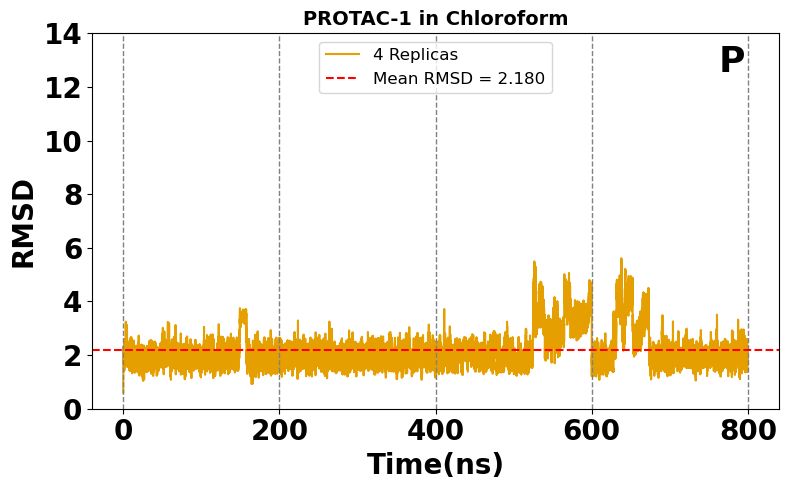

In [7]:
import numpy as np
import matplotlib.pyplot as plt

rmsd5 = R5.rmsd.T

# frame to time
time = rmsd5[0] / 50

# mean RMSD
mean_rmsd = np.mean(rmsd5[2])

# create figure and axis
fig, ax = plt.subplots(figsize=(8, 5))

# main RMSD curve
ax.plot(time, rmsd5[2], color='#E69F00', label="4 Replicas")

# vertical lines every 200
for x in np.arange(0, time.max() + 200, 200):
    ax.axvline(x=x, color='gray', linestyle='--', linewidth=1)

# mean RMSD line
ax.axhline(
    y=mean_rmsd,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label=f'Mean RMSD = {mean_rmsd:.3f}'
)

# labels and title
ax.set_xlabel("Time(ns)", fontsize=20, fontweight='bold')
ax.set_ylabel("RMSD", fontsize=20, fontweight='bold')
ax.set_title(trjname, fontsize=14, fontweight='bold')

# tick label size
ax.tick_params(axis='both', labelsize=14)

# add "NP" inside the plot box, top right
ax.text(
    0.95, 0.97, "P",
    transform=ax.transAxes,
    fontsize=26,
    fontweight='bold',
    ha='right',
    va='top'
)


# add legend
ax.legend(fontsize=12, loc='best')

# tick labels
ax.tick_params(axis='both', labelsize=20)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')

# y-axis limits and ticks
ax.set_ylim(0, 14)
ax.set_yticks([0, 2, 4, 6, 8, 10, 12, 14])

# adjust layout and save
plt.tight_layout()
plt.savefig(trjname + '_rmsd_all.png', bbox_inches='tight')
plt.show()

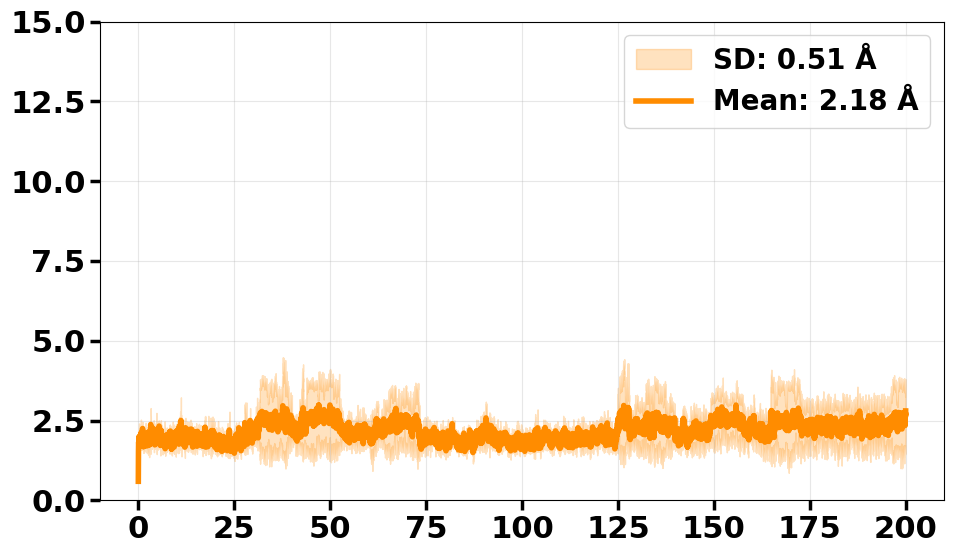

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# SETTINGS
xlim = (-10, 210)       # Time range in ns
ylim = (0, 15)        # RMSD range in Å


# PLOT STYLE
plt.rcParams.update({
    "font.size": 22,
    "font.weight": "bold",
    "axes.labelsize": 28,
    "axes.labelweight": "bold",
    "axes.titlesize": 30,
    "axes.titleweight": "bold",
    "xtick.labelsize": 22,
    "ytick.labelsize": 22,
    "legend.fontsize": 20,
})


# RMSD DATA
r1 = R1.rmsd[:, 2]
r2 = R2.rmsd[:, 2]
r3 = R3.rmsd[:, 2]
r4 = R4.rmsd[:, 2]

min_len = min(
    len(r1),
    len(r2),
    len(r3),
    len(r4)
)

r1 = r1[:min_len]
r2 = r2[:min_len]
r3 = r3[:min_len]
r4 = r4[:min_len]

time = np.arange(min_len) / 50

r_all = np.vstack([
    r1,
    r2,
    r3,
    r4
])

r_mean = np.mean(r_all, axis=0)
r_std = np.std(r_all, axis=0)

mean_val = np.mean(r_mean)
std_val = np.mean(r_std)

# PLOT

fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.fill_between(
    time,
    r_mean - r_std,
    r_mean + r_std,
    color="darkorange",
    alpha=0.25,
    label=f"SD: {std_val:.2f} Å"
)

ax.plot(
    time,
    r_mean,
    color="darkorange",
    linewidth=4,
    label=f"Mean: {mean_val:.2f} Å"
)

# Optional labels and title
# ax.set_xlabel("Time (ns)")
# ax.set_ylabel("RMSD (Å)")
# ax.set_title(f"RMSD Mean ± SD — {trjname}")

# AXIS LIMITS
ax.set_xlim(xlim)
ax.set_ylim(ylim)

# FORMATTING
ax.grid(alpha=0.3)
ax.legend()

ax.tick_params(
    axis="both",
    labelsize=22,
    width=2.5,
    length=7
)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight("bold")


plt.tight_layout()

plt.savefig(
    f"rmsd_mean_sd_{trjname}.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()